In [3]:
!pip install numpy pandas matplotlib seaborn tensorflow scikit-learn -q

In [6]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, LSTM, Dense, Dropout

In [8]:
df = pd.read_csv("C:\\Users\\lugoc\\Downloads\\IMDB Dataset.csv")

In [9]:
print(df.head())

                                              review sentiment
0  One of the other reviewers has mentioned that ...  positive
1  A wonderful little production. <br /><br />The...  positive
2  I thought this was a wonderful way to spend ti...  positive
3  Basically there's a family where a little boy ...  negative
4  Petter Mattei's "Love in the Time of Money" is...  positive


In [10]:
print(df['sentiment'].value_counts())

sentiment
positive    25000
negative    25000
Name: count, dtype: int64


In [13]:
#Limpieza y procesamiento
import re #Libreria expresiones regulares
def limpiar_texto(texto):
    #eliminar etiquetas html
    texto = re.sub(r'<.*?>', '', texto) #re.sub reemplaza
    #Eliminar caracteres especiales y puntuaciones, mantener los espacios
    texto = re.sub(r'[^a-zA-Z0-9\s]','', texto)
    #convertir a minusculas
    texto = texto.lower().strip()
    return texto

In [14]:
df['cleaned_review'] = df['review'].apply(limpiar_texto)
df.head()

,review,sentiment,cleaned_review
0,One of the other reviewers has mentioned that ...,positive,one of the other reviewers has mentioned that ...
1,A wonderful little production. <br /><br />The...,positive,a wonderful little production the filming tech...
2,I thought this was a wonderful way to spend ti...,positive,i thought this was a wonderful way to spend ti...
3,Basically there's a family where a little boy ...,negative,basically theres a family where a little boy j...
4,"Petter Mattei's ""Love in the Time of Money"" is...",positive,petter matteis love in the time of money is a ...


In [18]:
#Tokenizacion y padding
vocab_size = 10000 #Es el maximo numero de palabras en el vocabulario
max_length = 100 #longitud maxima de cada secuencia

In [19]:
tokenizer = Tokenizer(num_words=vocab_size)
tokenizer.fit_on_texts(df['cleaned_review'])

In [20]:
#Convertir las reviews en secuencias
sequences = tokenizer.texts_to_sequences(df['cleaned_review'])

In [21]:
#Rellenar las secuencias para que todas tengan la misma longitud (padear)
padded_sequences = pad_sequences(sequences, maxlen=max_length, padding='post', truncating='post')

In [26]:
#convertir las etiquetas sentimentales en 0 y 1
mapping = {'positive': 1, 'negative': 0}

# Aplicamos el cambio y forzamos la inferencia de tipos
df['sentiment'] = df['sentiment'].replace(mapping).infer_objects(copy=False)

C:\Users\lugoc\AppData\Local\Temp\ipykernel_12204\3320788486.py:5: Pandas4Warning: The copy keyword is deprecated and will be removed in a future version. Copy-on-Write is active in pandas since 3.0 which utilizes a lazy copy mechanism that defers copies until necessary. Use .copy() to make an eager copy if necessary.
  df['sentiment'] = df['sentiment'].replace(mapping).infer_objects(copy=False)


In [27]:
print("Tamaño del dataset (padded_sequences):", padded_sequences.shape)
print("Ejemplo de secuencia tokenizada:", padded_sequences[0])
print("Ejemplo de etiqueta:", sentiment[0])

Tamaño del dataset (padded_sequences): (50000, 100)
Ejemplo de secuencia tokenizada: [  27    4    1   77 1928   42 1057   11  100  144   39  504 3329  393
  456   25 3147   33   22  204   13   10    6  592   46  581   14 7543
   87  145   11 3220   68   41 3329   12   28 5511    2  131    4  583
   60  282    7  204   35    1  660  137 1723   68   10    6   20    3
  117   15    1 8157 5706   38   10  117 2479   54 5961   14 5619    5
 1456  381   38  583   28    6 3383    7    1  350  337    4    1    6
  461 3329   13   11    6    1  344    5    1 6796 2539 1055    8 2603
 1364   19]
Ejemplo de etiqueta: 1


In [30]:
#Separacion de entrenamiento y validacion
from sklearn.model_selection import train_test_split
#Sentiment debe ser int antes de dividir
sentiment = np.array(sentiment, dtype=np.int32)

X_train, X_test, y_train, y_test = train_test_split(
    padded_sequences,
    sentiment, test_size=0.2,
    random_state=42
)

print(f"Tamaño de X_train:{X_train.shape}")
print(f"Tamaño de X_test:{X_test.shape}")

Tamaño de X_train:(40000, 100)
Tamaño de X_test:(10000, 100)


In [31]:
#Diseñar la arquitectura del modelo
embedding_dim = 32 #Dimension de la capa de embedding (cada palabra se transforma en un vector de tam 32

model = Sequential() #red neuronal
model.add(Embedding(input_dim=vocab_size, output_dim = embedding_dim)) #capa 1
model.add(LSTM(64, return_sequences=False)) #capa 2 (LSTM LONG SHORT TEST MEMORY) RED NEURONAL PARA CADENAS DE TEXTO 64 NEURONAS
model.add(Dropout(0.5)) #capa 3 APAGA EL 50% DE LAS NEURONAS
model.add(Dense(1, activation='sigmoid')) #capa 4- 1 neurona convierte 0 y 1

model.compile(loss='binary_crossentropy', 
              optimizer='adam',
              metrics=['accuracy'])

In [33]:
#Entrenamiento del modelo
epochs = 5
batch_size = 128

history = model.fit(
    X_train,
    y_train,
    validation_data=(X_test, y_test),
    epochs = epochs, 
    batch_size=batch_size,
    verbose=1
)

Epoch 1/5
313/313 ━━━━━━━━━━━━━━━━━━━━ 23s 64ms/step - accuracy: 0.7295 - loss: 0.5087 - val_accuracy: 0.8357 - val_loss: 0.3754
Epoch 2/5
313/313 ━━━━━━━━━━━━━━━━━━━━ 17s 53ms/step - accuracy: 0.8646 - loss: 0.3327 - val_accuracy: 0.8448 - val_loss: 0.3565
Epoch 3/5
313/313 ━━━━━━━━━━━━━━━━━━━━ 20s 63ms/step - accuracy: 0.8874 - loss: 0.2823 - val_accuracy: 0.8394 - val_loss: 0.3791
Epoch 4/5
313/313 ━━━━━━━━━━━━━━━━━━━━ 20s 63ms/step - accuracy: 0.9024 - loss: 0.2481 - val_accuracy: 0.8379 - val_loss: 0.4183
Epoch 5/5
313/313 ━━━━━━━━━━━━━━━━━━━━ 20s 64ms/step - accuracy: 0.9148 - loss: 0.2175 - val_accuracy: 0.8340 - val_loss: 0.4417


In [34]:
loss, accuracy = model.evaluate(X_test, y_test, verbose=0)
print(f"Accuracy en el conjunto de validacion: {accuracy*100:.2f}%")

Accuracy en el conjunto de validacion: 83.40%


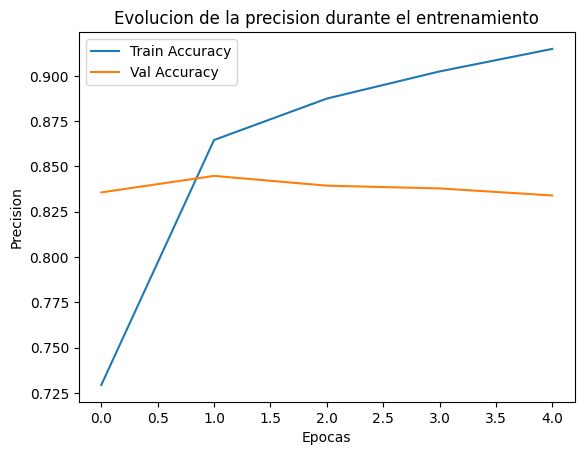

In [35]:
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Val Accuracy')
plt.title('Evolucion de la precision durante el entrenamiento')
plt.xlabel('Epocas')
plt.ylabel('Precision')
plt.legend()

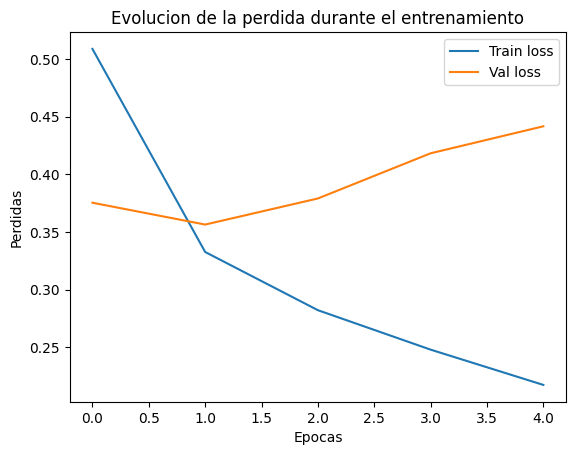

In [36]:
plt.plot(history.history['loss'], label='Train loss')
plt.plot(history.history['val_loss'], label='Val loss')
plt.title('Evolucion de la perdida durante el entrenamiento')
plt.xlabel('Epocas')
plt.ylabel('Perdidas')
plt.legend()
plt.show()